# Interactive Widgets Examples

Two approaches to link sliders to live plots.

## Example 1 — `interact` (simplest)

`interact` auto-generates a slider from the function signature and re-calls the function on every change.

In [ ]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, FloatSlider

x = np.linspace(0, 2 * np.pi, 300)

fig, ax = plt.subplots()
(line,) = ax.plot(x, np.sin(x))
ax.set_ylim(-2, 2)

def update(frequency=1.0, amplitude=1.0):
    line.set_ydata(amplitude * np.sin(frequency * x))
    fig.canvas.draw_idle()

interact(
    update,
    frequency=FloatSlider(value=1.0, min=0.5, max=5.0, step=0.1),
    amplitude=FloatSlider(value=1.0, min=0.1, max=2.0, step=0.1),
);

## Example 2 — Manual `observe` (more control)

Use `.observe()` when you want fine-grained control: display widgets and plots independently, or react to only specific widget changes.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display

x = np.linspace(0, 2 * np.pi, 300)

freq_slider = widgets.FloatSlider(value=1.0, min=0.5, max=5.0, step=0.1, description="Frequency")
amp_slider  = widgets.FloatSlider(value=1.0, min=0.1, max=2.0, step=0.1, description="Amplitude")

fig2, ax2 = plt.subplots()
(line2,) = ax2.plot(x, np.sin(x))
ax2.set_ylim(-2, 2)

def on_change(change):
    line2.set_ydata(amp_slider.value * np.sin(freq_slider.value * x))
    fig2.canvas.draw_idle()

freq_slider.observe(on_change, names="value")
amp_slider.observe(on_change, names="value")

display(widgets.VBox([freq_slider, amp_slider]))

## Example 3 — `FuncAnimation`

`FuncAnimation` calls an update function on each frame. The key parts:
- `init_func` sets the starting state
- `func` (here `animate`) receives the frame number and mutates the artists
- `blit=True` only redraws what changed — faster

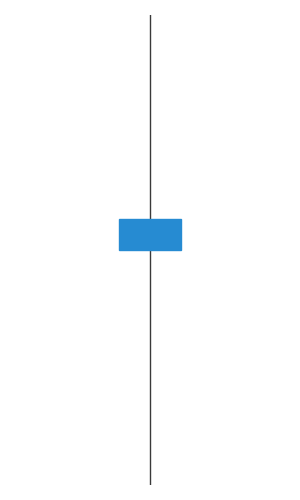

In [6]:
%matplotlib widget
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.animation as animation
import numpy as np

fig, ax = plt.subplots(figsize=(3, 5))
ax.set_xlim(0, 1)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect("equal")
ax.axis("off")

# The block: Rectangle(xy_bottom_left, width, height)
block_w, block_h = 0.4, 0.2
block = patches.Rectangle((0.3, 0), block_w, block_h, color="#268bd2")
ax.add_patch(block)

# Vertical guide rail
ax.axvline(0.5, color="#3a3a3a", linewidth=1, zorder=0)

t = np.linspace(0, 2 * np.pi, 120)  # 120 frames per cycle

def init():
    block.set_y(0)
    return (block,)

def animate(frame):
    y = np.sin(t[frame])          # oscillates between -1 and 1
    block.set_y(y - block_h / 2)  # center the block on y
    return (block,)

ani = animation.FuncAnimation(
    fig,
    animate,
    frames=len(t),
    init_func=init,
    interval=30,   # ms between frames (~33 fps)
    blit=True,
    repeat=True,
)

plt.tight_layout()
plt.show()


## Example 4 — Rotating rectangle about a pivot point

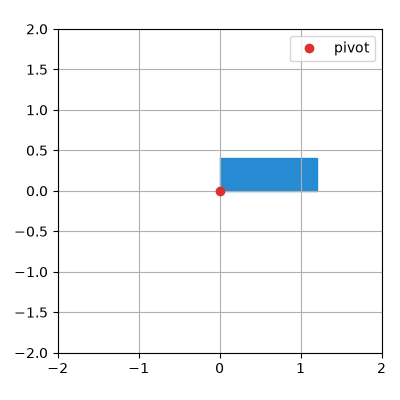

In [ ]:
%matplotlib widget
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.animation as animation
import matplotlib.transforms as transforms
import numpy as np

fig, ax = plt.subplots(figsize=(4, 4))
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_aspect("equal")
ax.grid(True)

# Rectangle bottom-left corner, width, height
rect_x, rect_y = 0.0, 0.0
rect_w, rect_h = 1.2, 0.4

rect = patches.Rectangle((rect_x, rect_y), rect_w, rect_h, color="#268bd2")
ax.add_patch(rect)

# Pivot point — bottom-left corner of the rectangle
pivot_x, pivot_y = rect_x, rect_y
ax.plot(pivot_x, pivot_y, "o", color="#dc322f", zorder=5, label="pivot")
ax.legend()

# def animate(frame):
#     angle = frame * 3  # degrees per frame
#     rot = transforms.Affine2D().rotate_around(pivot_x, pivot_y, np.deg2rad(angle))
#     rect.set_transform(rot + ax.transData)
#     return (rect,)

# ani = animation.FuncAnimation(
#     fig,
#     animate,
#     frames=120,
#     interval=30,
#     blit=True,
#     repeat=False,
# )

plt.tight_layout()
plt.show()